In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fftpack import fft

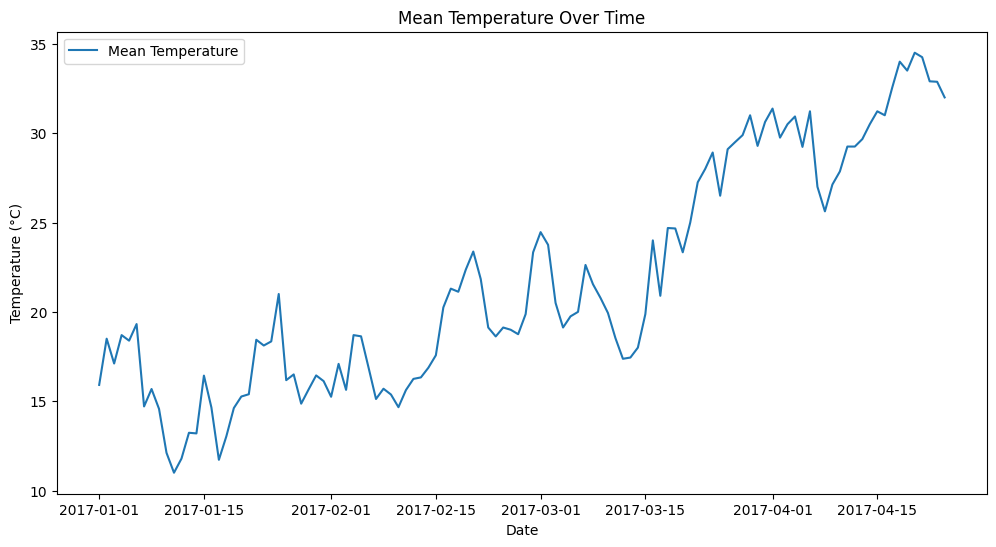

In [5]:
# Load the dataset
df = pd.read_csv("DailyDelhiClimateTest.csv", parse_dates=["date"], index_col="date")

# Enable inline plotting for Jupyter Notebook
%matplotlib inline

# Plot raw time series data
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y="meantemp", label="Mean Temperature")
plt.title("Mean Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

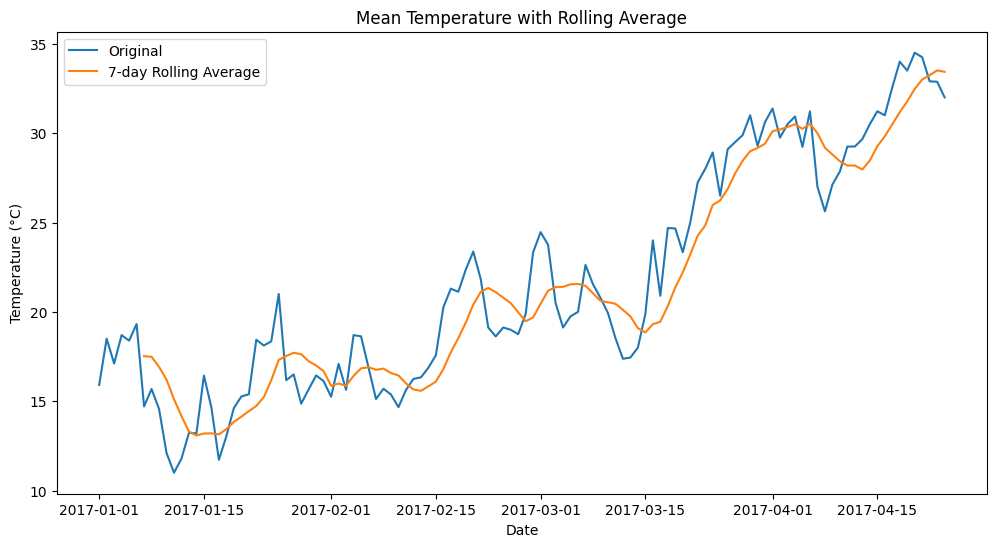

In [6]:
# Compute and plot rolling average (smoothing)
df["meantemp_rolling"] = df["meantemp"].rolling(window=7).mean()
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y="meantemp", label="Original")
sns.lineplot(data=df, x=df.index, y="meantemp_rolling", label="7-day Rolling Average")
plt.title("Mean Temperature with Rolling Average")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

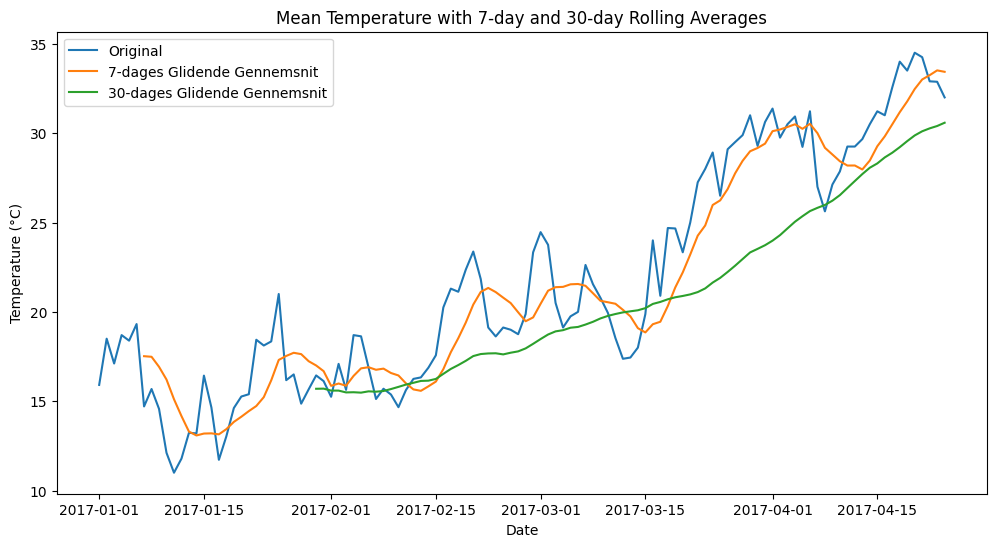

In [10]:
# Compute and plot rolling average (smoothing) with 7-day and 30-day windows
df["meantemp_rolling_7"] = df["meantemp"].rolling(window=7).mean()
df["meantemp_rolling_30"] = df["meantemp"].rolling(window=30).mean()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y="meantemp", label="Original")
sns.lineplot(data=df, x=df.index, y="meantemp_rolling_7", label="7-dages Glidende Gennemsnit")
sns.lineplot(data=df, x=df.index, y="meantemp_rolling_30", label="30-dages Glidende Gennemsnit")
plt.title("Mean Temperature with 7-day and 30-day Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

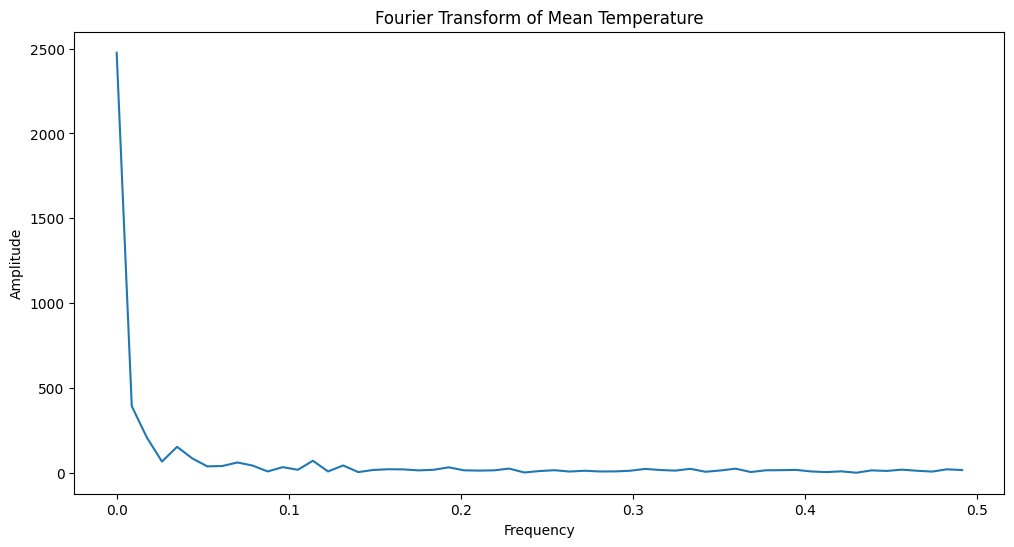

Analysis complete: Visualizations show raw data, smoothed trends, and frequency components.


In [9]:
# Perform Fourier Transform to analyze frequency components
if "meantemp" in df.columns:
    try:
        # Use numpy's FFT instead of scipy's
        temp_fft = np.fft.fft(df["meantemp"].dropna().values)  # Use .values to get numpy array
        n = len(temp_fft)
        amplitudes = np.abs(temp_fft)[:n//2]
        frequencies = np.fft.fftfreq(n, d=1)[:n//2]

        plt.figure(figsize=(12, 6))
        plt.plot(frequencies, amplitudes)
        plt.title("Fourier Transform of Mean Temperature")
        plt.xlabel("Frequency")
        plt.ylabel("Amplitude")
        plt.show()
    except Exception as e:
        print(f"Error performing FFT: {str(e)}")
else:
    print("Error: 'meantemp' column not found in DataFrame. Available columns:", df.columns)

print("Analysis complete: Visualizations show raw data, smoothed trends, and frequency components.")